# NOAA Tide Gauge Data Processing

This notebook processes NOAA tide gauge data for selected stations in and around the Chesapeake Bay region. The goal is to estimate relative sea level rise rates for each station using monthly mean sea level data from 1994 through 2024.

The resulting station-level RSLR rates are saved as a CSV file so they can be used later in the final project report, where tide gauge data are compared with salinity trends and potential ghost forest transition pixels.

In [1]:
# --- 1. SETUP & CONFIGURATION ---

from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define project folders
DATA_DIR = Path("../Data")
OTHER_MATERIALS_DIR = Path("../OtherMaterials")

# List of NOAA station IDs for the Chesapeake Bay area
station_ids = [
    "8635750", "8639348", "8638610", "8638901", "8632200", "8637689",
    "8571421", "8636580", "8577330", "8635027", "8571892", "8594900",
    "8575512", "8573364", "8574680", "8573927"
]

# Dictionary to store results for the final map and summary table
station_data_summary = {}

## Setup and Configuration

This first code cell imports the Python libraries needed to download, process, analyze, and map NOAA tide gauge data. The `requests` library is used to retrieve data from the NOAA APIs, `pandas` is used to organize the data into tables, `scipy.stats.linregress` is used to calculate linear sea level trends, and `cartopy` is used to map the station locations.

The code also defines relative paths to the project `Data` and `OtherMaterials` folders. Because this notebook is stored inside the `Code` folder, the path `../Data` points back to the main project folder and then into the `Data` folder. This helps ensure that output files are saved in the correct project location instead of being saved loosely inside the `Code` folder.

Processing: Lewisetta, VA...
Processing: Money Point, VA...
Processing: Sewells Point, VA...
Processing: CBBT, Chesapeake Channel, VA...
Processing: Kiptopeke, VA...
Processing: Yorktown USCG Training Center, VA...
Processing: Bishops Head, MD...
Processing: Windmill Point, VA...
Processing: Solomons Island, MD...
Processing: Dahlgren, VA...
Processing: Cambridge, MD...
Processing: Washington, DC...
Processing: Annapolis, MD...
Processing: Tolchester Beach, MD...
Processing: Baltimore, MD...
Processing: Chesapeake City, MD...


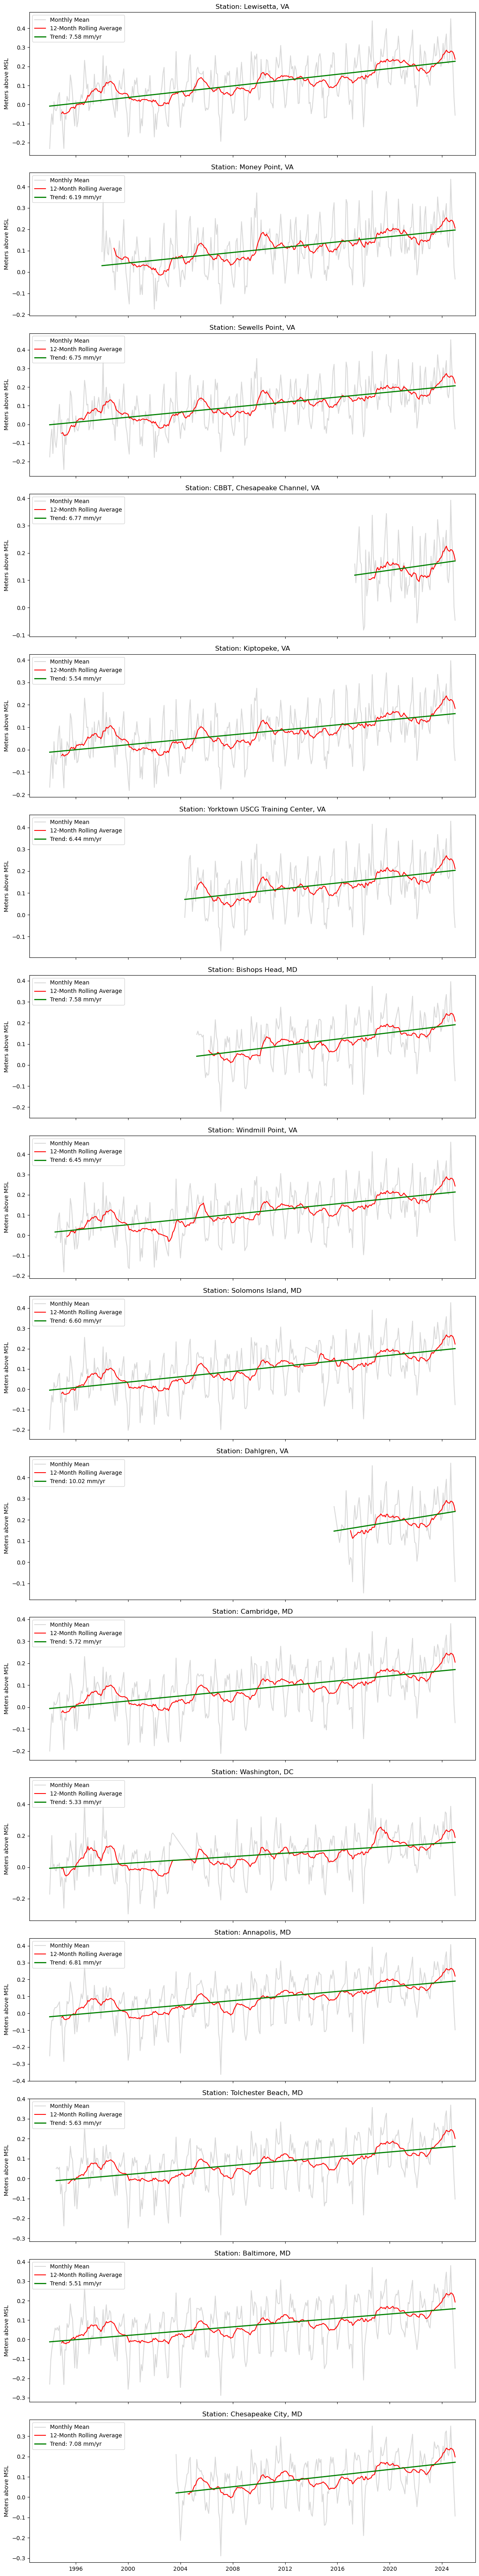

In [2]:
# --- 2. DATA PROCESSING LOOP ---

# Initialize the figure for time-series subplots
fig_ts, axes = plt.subplots(
    nrows=len(station_ids),
    ncols=1,
    figsize=(12, 4 * len(station_ids)),
    sharex=True
)

for i, station_id in enumerate(station_ids):
    try:
        # A. Fetch metadata: station name, state, latitude, and longitude
        meta_url = f"https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations/{station_id}.json"
        meta_res = requests.get(meta_url)
        meta_res.raise_for_status()
        meta_json = meta_res.json()
        
        s_info = meta_json["stations"][0]
        s_name = f"{s_info['name']}, {s_info['state']}"
        s_lat = float(s_info["lat"])
        s_lon = float(s_info["lng"])
        
        print(f"Processing: {s_name}...")

        # B. Fetch monthly mean sea level data
        params = {
            "begin_date": "19940101",
            "end_date": "20241231",
            "station": station_id,
            "product": "monthly_mean",
            "datum": "MSL",
            "units": "metric",
            "time_zone": "lst_ldt",
            "format": "json"
        }
        
        data_res = requests.get(
            "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter",
            params=params
        )
        data_res.raise_for_status()
        data = data_res.json()

        if "data" not in data:
            print(f"  ! No data found for {s_name}.")
            continue

        # C. Clean data with Pandas
        df = pd.DataFrame(data["data"])
        df["timestamp"] = pd.to_datetime(df["year"] + "-" + df["month"])
        df["sea_level"] = pd.to_numeric(df["MSL"], errors="coerce")
        df.set_index("timestamp", inplace=True)
        df = df[["sea_level"]].dropna()

        # D. Linear regression to calculate RSLR rate
        x = df.index.map(pd.Timestamp.toordinal)
        y = df["sea_level"]

        slope, intercept, r_val, p_val, std_err = linregress(x, y)

        # Convert slope from meters per day to millimeters per year
        rate_mm_yr = slope * 365.25 * 1000

        # Store results for the map and summary table
        station_data_summary[station_id] = {
            "name": s_name,
            "lat": s_lat,
            "lon": s_lon,
            "rate": rate_mm_yr
        }

        # E. Plot individual station trend
        ax = axes[i]
        ax.plot(
            df.index,
            df["sea_level"],
            label="Monthly Mean",
            alpha=0.3,
            color="gray"
        )
        ax.plot(
            df.index,
            df["sea_level"].rolling(window=12).mean(),
            label="12-Month Rolling Average",
            color="red"
        )
        ax.plot(
            df.index,
            intercept + slope * x,
            color="green",
            linewidth=2,
            label=f"Trend: {rate_mm_yr:.2f} mm/yr"
        )

        ax.set_title(f"Station: {s_name}")
        ax.set_ylabel("Meters above MSL")
        ax.legend(loc="upper left")

    except Exception as e:
        print(f"Error processing {station_id}: {e}")

# Format and save the time-series plot
plt.tight_layout()
plt.savefig(
    OTHER_MATERIALS_DIR / "RSLR_TimeSeries_Trends.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Downloading NOAA Tide Gauge Data and Calculating RSLR Trends

This code cell loops through each selected NOAA tide gauge station. For each station, it first retrieves station metadata from the NOAA CO-OPS Metadata API, including the station name, state, latitude, and longitude. These coordinates are needed later for mapping and spatial analysis.

The code then downloads monthly mean sea level data from the NOAA CO-OPS Data API for the period from 1994 through 2024. Monthly mean sea level was used because it provides a long-term water level record that is appropriate for estimating relative sea level rise trends.

After the data are downloaded, the code cleans the time series by converting dates into datetime format and converting mean sea level values into numeric values. A linear regression is then fit to each station’s water level record. The slope of the regression line represents the rate of sea level change through time. Because the original slope is calculated in meters per day, it is converted to millimeters per year.

The time-series plots show the monthly mean sea level values, a 12-month rolling average, and the fitted linear trend for each tide gauge station. These plots help visually check whether the calculated RSLR rates are reasonable.

In [3]:
# --- 3. SUMMARY TABLE ---

# Convert the dictionary to a Pandas DataFrame
rslr_df = pd.DataFrame.from_dict(station_data_summary, orient="index")

# Reset the index so Station ID becomes a normal column
rslr_df.index.name = "Station ID"
rslr_df = rslr_df.reset_index()

# Rename columns for clarity
rslr_df.columns = ["Station ID", "Area", "Lat", "Lon", "Rate (mm/yr)"]

# Export the DataFrame to the Data folder
output_path = DATA_DIR / "RSLR_Trend_Summary.csv"
rslr_df.to_csv(output_path, index=False)

print(f"\nDetailed summary saved to '{output_path}'")

rslr_df


Detailed summary saved to '../Data/RSLR_Trend_Summary.csv'


,Station ID,Area,Lat,Lon,Rate (mm/yr)
0,8635750,"Lewisetta, VA",37.996100,-76.464400,7.579530
1,8639348,"Money Point, VA",36.778194,-76.301865,6.186681
2,8638610,"Sewells Point, VA",36.942780,-76.328610,6.746291
3,8638901,"CBBT, Chesapeake Channel, VA",37.032900,-76.083300,6.773640
4,8632200,"Kiptopeke, VA",37.165200,-75.988400,5.544813
5,8637689,"Yorktown USCG Training Center, VA",37.226500,-76.478806,6.438762
6,8571421,"Bishops Head, MD",38.220000,-76.038300,7.580189
7,8636580,"Windmill Point, VA",37.615500,-76.289780,6.448224
8,8577330,"Solomons Island, MD",38.316700,-76.451700,6.602620
9,8635027,"Dahlgren, VA",38.319750,-77.036600,10.020287


## Creating the RSLR Summary Table

The previous code cell stored each station’s calculated relative sea level rise rate in a dictionary. This code cell converts that dictionary into a Pandas DataFrame so the results are easier to view, export, and use in later analysis.

Each row in the summary table represents one NOAA tide gauge station. The table includes the station ID, station area, latitude, longitude, and estimated RSLR rate in millimeters per year.

The summary table is exported to the project `Data` folder as `RSLR_Trend_Summary.csv`. This is important because the final project report can read this file directly instead of recalculating the NOAA trends from scratch every time.

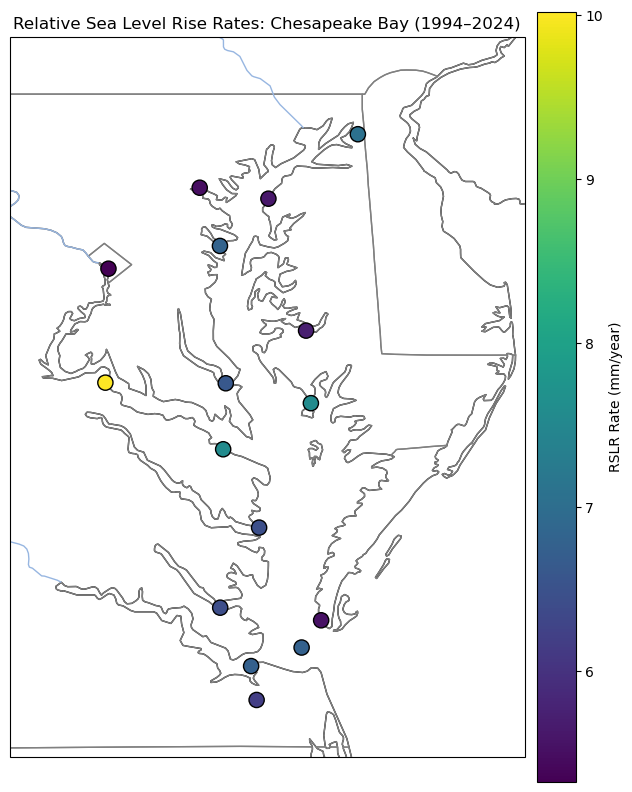

In [4]:
# --- 4. GEOGRAPHIC MAP OF RSLR RATES ---

# Extract longitude, latitude, and RSLR rate values
lons = [info["lon"] for info in station_data_summary.values()]
lats = [info["lat"] for info in station_data_summary.values()]
rates = [info["rate"] for info in station_data_summary.values()]

# Create map figure
fig_map = plt.figure(figsize=(8, 10))
ax_map = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax_map.add_feature(cfeature.COASTLINE)
ax_map.add_feature(cfeature.STATES, edgecolor="gray")
ax_map.add_feature(cfeature.RIVERS)

# Set map extent around the Chesapeake Bay region
ax_map.set_extent([-77.5, -75.0, 36.5, 40.0], crs=ccrs.PlateCarree())

# Plot station points colored by RSLR rate
scatter = ax_map.scatter(
    lons,
    lats,
    c=rates,
    cmap="viridis",
    s=120,
    edgecolor="black",
    transform=ccrs.PlateCarree(),
    zorder=5
)

# Add colorbar and title
plt.colorbar(
    scatter,
    orientation="vertical",
    pad=0.02,
    label="RSLR Rate (mm/year)"
)

plt.title("Relative Sea Level Rise Rates: Chesapeake Bay (1994–2024)")

# Save and display map
plt.savefig(
    OTHER_MATERIALS_DIR / "RSLR_Station_Map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Mapping the NOAA Tide Gauge Stations

This map shows the locations of the NOAA tide gauge stations used in the project. Each point represents one station, and the color of the point represents the estimated relative sea level rise rate in millimeters per year.

Mapping the stations is useful because it confirms that the selected tide gauges are distributed across the Chesapeake Bay region. It also provides spatial context for the final analysis. Since the number of tide gauge stations is relatively small compared with the number of salinity stations or NLCD pixels, the tide gauge stations are used as the spatial anchor for the project. Later in the workflow, buffers are created around these stations so nearby salinity trends and potential ghost forest transition pixels can be summarized within a consistent area.